# 4. From individual binaries to a population

**FQCP 2026 · Bayesian parameter estimation for gravitational-wave sources**

> Designed for Google Colab. Run top to bottom; **Extension** sections may be skipped live.


## Goal

The detected catalogue is not the astrophysical population:
\[
p(\Lambda\mid\{d_i\},\mathrm{det})\propto p(\Lambda)\prod_i
\frac{\int p(d_i\mid\theta)p(\theta\mid\Lambda)d\theta}{\alpha(\Lambda)}.
\]
For clarity, masses are exact and only a population mean is inferred.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ
rng = np.random.default_rng(20260817)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["animation.html"] = "jshtml"
print("Running in Colab:", IN_COLAB)

Running in Colab: False


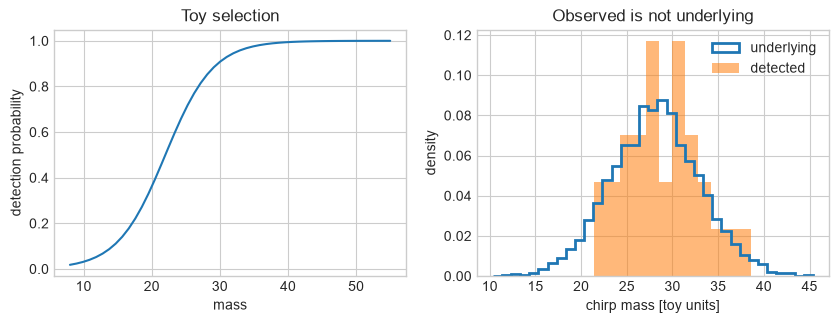

In [2]:
from scipy.stats import norm
true_mean,true_width=28.,5.; all_masses=rng.normal(true_mean,true_width,5000); all_masses=all_masses[(all_masses>8)&(all_masses<55)]
def p_detect(mass): return 1/(1+np.exp(-(mass-22)/3.5))
detected=all_masses[rng.random(all_masses.size)<p_detect(all_masses)][:30]
fig,axes=plt.subplots(1,2,figsize=(10,3.2)); grid=np.linspace(8,55)
axes[0].plot(grid,p_detect(grid)); axes[0].set(xlabel="mass",ylabel="detection probability",title="Toy selection")
axes[1].hist(all_masses,bins=35,density=True,histtype="step",lw=2,label="underlying"); axes[1].hist(detected,bins=12,density=True,alpha=.55,label="detected")
axes[1].set(xlabel="chirp mass [toy units]",ylabel="density",title="Observed is not underlying"); axes[1].legend(); plt.show()

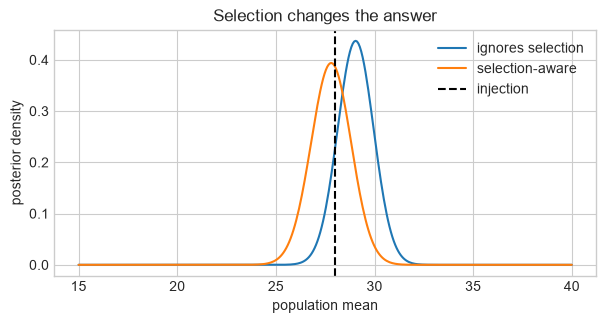

In [3]:
means=np.linspace(15,40,350); x=np.linspace(8,55,800); naive=[]; corrected=[]
for mean in means:
    event=norm.logpdf(detected,mean,true_width).sum(); alpha=np.trapezoid(norm.pdf(x,mean,true_width)*p_detect(x),x)
    naive.append(event); corrected.append(event-len(detected)*np.log(alpha))
def normalise(logp): p=np.exp(logp-np.max(logp)); return p/np.trapezoid(p,means)
fig,ax=plt.subplots(figsize=(7,3.2)); ax.plot(means,normalise(np.array(naive)),label="ignores selection"); ax.plot(means,normalise(np.array(corrected)),label="selection-aware")
ax.axvline(true_mean,color="k",ls="--",label="injection"); ax.set(xlabel="population mean",ylabel="posterior density",title="Selection changes the answer"); ax.legend(); plt.show()

## Boundary

Real analyses reuse uncertain event likelihoods/posteriors, infer several hyperparameters, estimate selection with injections, and may include the rate. Every earlier choice—PSD, waveform, response—affects the event posteriors being combined.